# Producing Figures for Publication

In [1]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Figure 1: Heatmap from RMSE Percentage Improvements

Looks at percentage changes from baseline to hybrid in the RMSE metric for all 5 hybrid model variations with different GPT feature lag structures (1-week to 5-week).

Description:

*Figure 1. Percent improvement in RMSE for hybrid models relative to baseline across commodities and GPT-feature lags. Negative values indicate lower hybrid error. Markers denote commodities with statistically significant Diebold–Mariano test results (p < 0.05).*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
import seaborn as sns

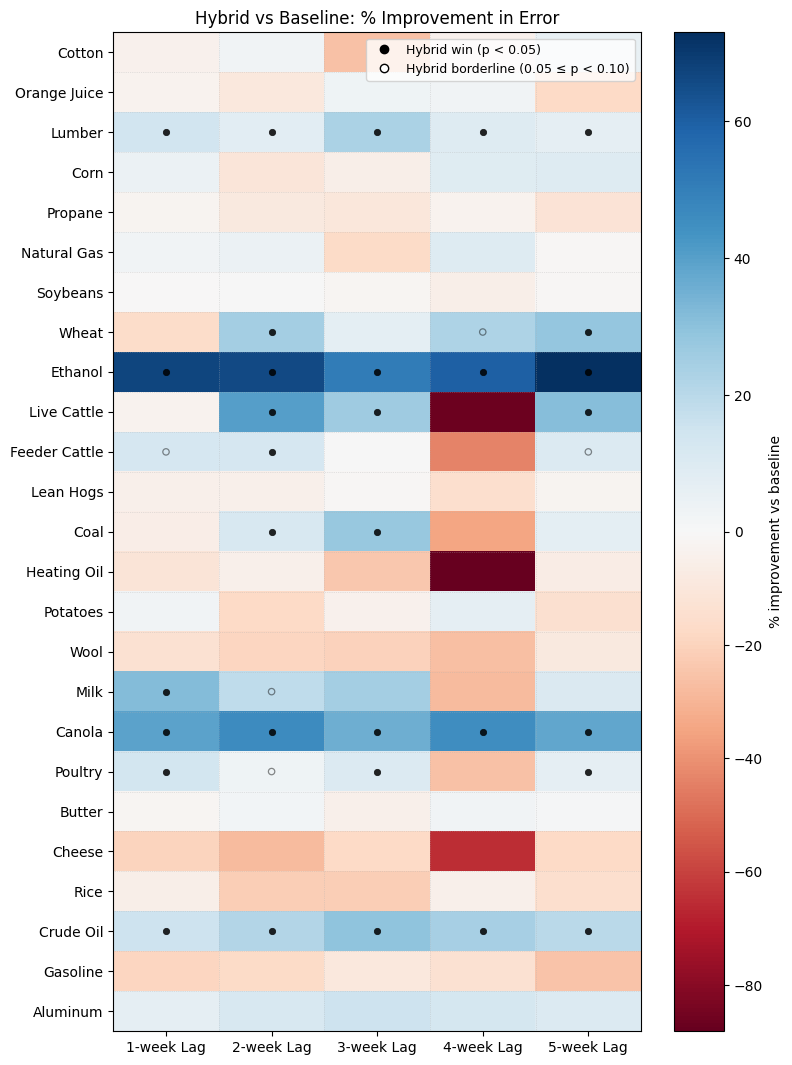

In [3]:
# -----------------------------
# 1) Load % change heatmap data
# -----------------------------
CSV_PATH = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/rmse_changes.csv"
df = pd.read_csv(CSV_PATH)

lag_cols = ['1-week Lag', '2-week Lag', '3-week Lag', '4-week Lag', '5-week Lag']

for col in lag_cols:
    df[col] = df[col] * -100

assert 'Commodity' in df.columns, "CSV must contain a 'Commodity' column."
for c in lag_cols:
    assert c in df.columns, f"CSV must contain '{c}' column."

df[lag_cols] = df[lag_cols].apply(pd.to_numeric, errors='coerce')

commodities = df['Commodity'].tolist()
M = df[lag_cols].to_numpy()  # shape: (n_commodities, 5)

# Diverging normalization centered at 0 (negative = improvement)
vmin = np.nanmin(M)
vmax = np.nanmax(M)
vmin = min(vmin, 0.0)
vmax = max(vmax, 0.0)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# -----------------------------
# 2) Load DM results for overlay
# -----------------------------
DM_CSV_PATH = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/dm_test_results.csv"
dm = pd.read_csv(DM_CSV_PATH)

# Expected columns:
# Commodity | dm_1w | pval_1w | dm_2w | pval_2w | dm_3w | pval_3w | dm_4w | pval_4w | dm_5w | pval_5w
required_dm_cols = ['Commodity'] + sum(([f'dm_{w}', f'pval_{w}'] for w in ['1w','2w','3w','4w','5w']), [])
required_dm_cols = ['Commodity','dm_1w','pval_1w','dm_2w','pval_2w','dm_3w','pval_3w','dm_4w','pval_4w','dm_5w','pval_5w']
for c in required_dm_cols:
    assert c in dm.columns, f"DM CSV missing required column: {c}"

# Align DM rows to heatmap order by merging on Commodity
dm = dm.merge(df[['Commodity']], on='Commodity', how='right')

# -----------------------------
# 3) Plot heatmap
# -----------------------------
n_rows = len(commodities)
height = 0.35 * n_rows + 2.0
fig, ax = plt.subplots(figsize=(8, height))

im = ax.imshow(M, aspect='auto', norm=norm, cmap='RdBu')

ax.set_xticks(np.arange(len(lag_cols)))
ax.set_xticklabels(lag_cols)
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(commodities)

# Light grid
ax.set_xticks(np.arange(-0.5, len(lag_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which='minor', linewidth=0.5, linestyle=':', alpha=0.6)
ax.tick_params(which='minor', length=0)

ax.set_title("Hybrid vs Baseline: % Improvement in Error")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("% improvement vs baseline")

# -----------------------------
# 4) Overlay DM significance
# -----------------------------
# Map heatmap lag columns to DM columns
lag_to_dm = {
    0: ('dm_1w','pval_1w'),
    1: ('dm_2w','pval_2w'),
    2: ('dm_3w','pval_3w'),
    3: ('dm_4w','pval_4w'),
    4: ('dm_5w','pval_5w'),
}

# Marker styles
alpha_sig = 0.85
alpha_border = 0.45
ms = 6.5  # marker size

for row_idx, _ in enumerate(commodities):
    for col_idx in range(5):
        dm_col, p_col = lag_to_dm[col_idx]
        dm_stat = dm.loc[row_idx, dm_col]
        p_val   = dm.loc[row_idx, p_col]

        # Skip if NaN
        if pd.isna(dm_stat) or pd.isna(p_val):
            continue

        x = col_idx
        y = row_idx

        # Significant
        if p_val < 0.05:
            if dm_stat > 0:  # hybrid better
                ax.scatter(x, y, marker='o', s=ms**2/2, edgecolors='black',
                           facecolors='black', alpha=alpha_sig, linewidths=0.5)
            # elif dm_stat < 0:  # baseline better
            #     ax.scatter(x, y, marker='x', s=ms**2/2, c='black',
            #                alpha=alpha_sig, linewidths=1.25)
        # Borderline
        elif 0.05 <= p_val < 0.10:
            if dm_stat > 0:  # borderline hybrid
                ax.scatter(x, y, marker='o', s=ms**2/2, edgecolors='black',
                           facecolors='none', alpha=alpha_border, linewidths=0.9)
            # elif dm_stat < 0:  # borderline baseline
            #     ax.scatter(x, y, marker='x', s=ms**2/2, c='black',
            #                alpha=alpha_border, linewidths=1.0)

# -----------------------------
# 5) Legend for overlays
# -----------------------------
legend_elems = [
    Line2D([0],[0], marker='o', color='black', markerfacecolor='black', markersize=6,
           linestyle='None', label='Hybrid win (p < 0.05)'),
    # Line2D([0],[0], marker='x', color='black', markersize=6,
    #        linestyle='None', label='Baseline win (p < 0.05)'),
    Line2D([0],[0], marker='o', color='black', markerfacecolor='white', markersize=6,
           linestyle='None', label='Hybrid borderline (0.05 ≤ p < 0.10)'),
    # Line2D([0],[0], marker='x', color='black', alpha=0.6, markersize=6,
    #        linestyle='None', label='Baseline borderline (0.05 ≤ p < 0.10)'),
]
ax.legend(handles=legend_elems, loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig("heatmap_fig.png", dpi=600, bbox_inches='tight')
plt.show()

## Figure 2: Lag-Response Curves for Key Commodities

*   Subset from Figure 1
*   Demonstrates % RMSE improvements for Lumber, Canola, Ethanol, and Crude Oil at the different lag structures

Description:

*Figure 2. Percentage improvement in RMSE relative to the baseline across GPT feature lags (1–5 weeks). Positive values indicate improved accuracy. Commodities such as Lumber, Ethanol, Canola, and Crude Oil show consistent gains, while Wheat, Live Cattle, and Coal exhibit non-monotonic patterns, reflecting delayed and feedback-driven propagation of weather-shock effects.*





In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.gridspec import GridSpec

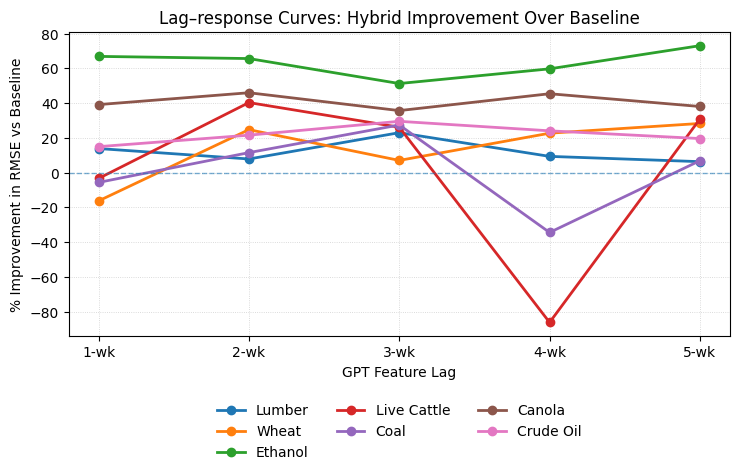

In [5]:
# ---- user-configurable path ----
CSV_PATH = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/rmse_changes.csv"  # set to your file path

# ---- load and validate ----
df = pd.read_csv(CSV_PATH)

lag_cols = ['1-week Lag', '2-week Lag', '3-week Lag', '4-week Lag', '5-week Lag']
assert 'Commodity' in df.columns, "CSV must contain a 'Commodity' column."
for c in lag_cols:
    assert c in df.columns, f"CSV must contain '{c}' column."

# ensure numeric
df[lag_cols] = df[lag_cols].apply(pd.to_numeric, errors='coerce')

# ---- select commodities to show ----
wanted = ['Lumber', 'Ethanol', 'Canola', 'Crude Oil', 'Wheat', 'Live Cattle', 'Coal']

# case-insensitive match helper
def match_names(df_names, wanted_names):
    lower_map = {name.lower(): name for name in df_names}
    matched = []
    missing = []
    for w in wanted_names:
        key = w.lower()
        if key in lower_map:
            matched.append(lower_map[key])
        else:
            missing.append(w)
    return matched, missing

available, missing = match_names(df['Commodity'].tolist(), wanted)
if missing:
    print("Warning: not found in CSV ->", missing)

df_sub = df[df['Commodity'].isin(available)].copy()

# ---- flip sign so positive = improvement ----
# original values are % change vs baseline (negative = improvement)
# we multiply by -1 for display only
Y = -df_sub[lag_cols].to_numpy() * 100   # shape (n_comms, 5)
x = np.arange(1, 6)

# ---- plotting ----
fig, ax = plt.subplots(figsize=(7.5, 5))  # wide, compact, journal-friendly

for i, (_, row) in enumerate(df_sub.iterrows()):
    ax.plot(x, Y[i, :], marker='o', linewidth=2, markersize=6, label=row['Commodity'])

# axes, ticks, grid
ax.set_xticks(x)
ax.set_xticklabels(['1-wk', '2-wk', '3-wk', '4-wk', '5-wk'])
ax.axhline(0, linewidth=1, linestyle='--', alpha=0.6)
ax.grid(True, axis='both', linestyle=':', linewidth=0.6, alpha=0.6)

# labels and title
ax.set_ylabel('% Improvement in RMSE vs Baseline')
ax.set_xlabel('GPT Feature Lag')
ax.set_title('Lag–response Curves: Hybrid Improvement Over Baseline')

# legend below the plot (single row if space allows)
leg = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
                ncol=3, frameon=False, handlelength=2)
plt.tight_layout()

# ---- export ----
out_png = Path("rmse_lag_response.png")
# out_pdf = Path("figure2_lag_response_curves.pdf")
fig.savefig(out_png, dpi=600, bbox_inches='tight')
# fig.savefig(out_pdf, bbox_inches='tight')
# print(f"Saved: {out_png.resolve()}")
# print(f"Saved: {out_pdf.resolve()}")
plt.show()

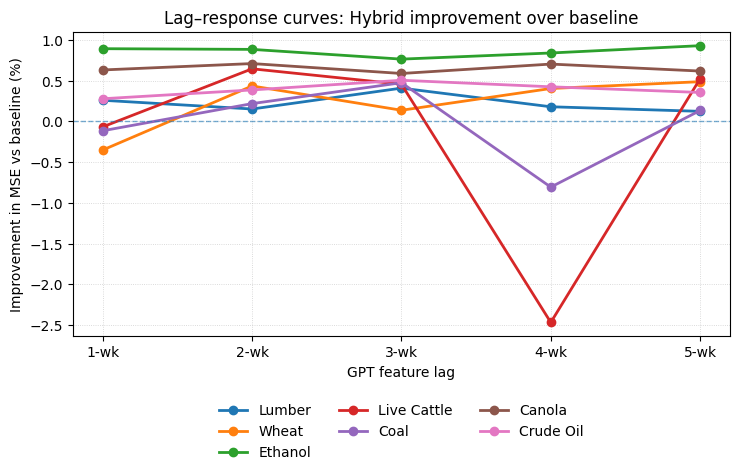

In [ ]:
# ---- user-configurable path ----
CSV_PATH = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/mse_changes.csv"  # set to your file path

# ---- load and validate ----
df = pd.read_csv(CSV_PATH)

lag_cols = ['1-week Lag', '2-week Lag', '3-week Lag', '4-week Lag', '5-week Lag']
assert 'Commodity' in df.columns, "CSV must contain a 'Commodity' column."
for c in lag_cols:
    assert c in df.columns, f"CSV must contain '{c}' column."

# ensure numeric
df[lag_cols] = df[lag_cols].apply(pd.to_numeric, errors='coerce')

# ---- select commodities to show ----
wanted = ['Lumber', 'Ethanol', 'Canola', 'Crude Oil', 'Wheat', 'Live Cattle', 'Coal']

# case-insensitive match helper
def match_names(df_names, wanted_names):
    lower_map = {name.lower(): name for name in df_names}
    matched = []
    missing = []
    for w in wanted_names:
        key = w.lower()
        if key in lower_map:
            matched.append(lower_map[key])
        else:
            missing.append(w)
    return matched, missing

available, missing = match_names(df['Commodity'].tolist(), wanted)
if missing:
    print("Warning: not found in CSV ->", missing)

df_sub = df[df['Commodity'].isin(available)].copy()

# ---- flip sign so positive = improvement ----
# original values are % change vs baseline (negative = improvement)
# we multiply by -1 for display only
Y = -df_sub[lag_cols].to_numpy()   # shape (n_comms, 5)
x = np.arange(1, 6)

# ---- plotting ----
fig, ax = plt.subplots(figsize=(7.5, 5))  # wide, compact, journal-friendly

for i, (_, row) in enumerate(df_sub.iterrows()):
    ax.plot(x, Y[i, :], marker='o', linewidth=2, markersize=6, label=row['Commodity'])

# axes, ticks, grid
ax.set_xticks(x)
ax.set_xticklabels(['1-wk', '2-wk', '3-wk', '4-wk', '5-wk'])
ax.axhline(0, linewidth=1, linestyle='--', alpha=0.6)
ax.grid(True, axis='both', linestyle=':', linewidth=0.6, alpha=0.6)

# labels and title
ax.set_ylabel('Improvement in MSE vs baseline (%)')
ax.set_xlabel('GPT feature lag')
ax.set_title('Lag–response curves: Hybrid improvement over baseline')

# legend below the plot (single row if space allows)
leg = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
                ncol=3, frameon=False, handlelength=2)
plt.tight_layout()

# ---- export ----
# out_png = Path("figure2_lag_response_curves.png")
# out_pdf = Path("figure2_lag_response_curves.pdf")
# fig.savefig(out_png, dpi=300, bbox_inches='tight')
# fig.savefig(out_pdf, bbox_inches='tight')
# print(f"Saved: {out_png.resolve()}")
# print(f"Saved: {out_pdf.resolve()}")
plt.show()

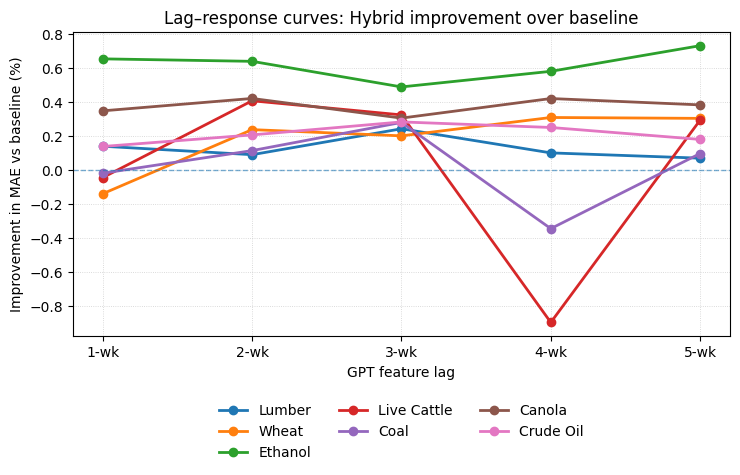

In [ ]:
# ---- user-configurable path ----
CSV_PATH = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/mae_changes.csv"  # set to your file path

# ---- load and validate ----
df = pd.read_csv(CSV_PATH)

lag_cols = ['1-week Lag', '2-week Lag', '3-week Lag', '4-week Lag', '5-week Lag']
assert 'Commodity' in df.columns, "CSV must contain a 'Commodity' column."
for c in lag_cols:
    assert c in df.columns, f"CSV must contain '{c}' column."

# ensure numeric
df[lag_cols] = df[lag_cols].apply(pd.to_numeric, errors='coerce')

# ---- select commodities to show ----
wanted = ['Lumber', 'Ethanol', 'Canola', 'Crude Oil', 'Wheat', 'Live Cattle', 'Coal']

# case-insensitive match helper
def match_names(df_names, wanted_names):
    lower_map = {name.lower(): name for name in df_names}
    matched = []
    missing = []
    for w in wanted_names:
        key = w.lower()
        if key in lower_map:
            matched.append(lower_map[key])
        else:
            missing.append(w)
    return matched, missing

available, missing = match_names(df['Commodity'].tolist(), wanted)
if missing:
    print("Warning: not found in CSV ->", missing)

df_sub = df[df['Commodity'].isin(available)].copy()

# ---- flip sign so positive = improvement ----
# original values are % change vs baseline (negative = improvement)
# we multiply by -1 for display only
Y = -df_sub[lag_cols].to_numpy()   # shape (n_comms, 5)
x = np.arange(1, 6)

# ---- plotting ----
fig, ax = plt.subplots(figsize=(7.5, 5))  # wide, compact, journal-friendly

for i, (_, row) in enumerate(df_sub.iterrows()):
    ax.plot(x, Y[i, :], marker='o', linewidth=2, markersize=6, label=row['Commodity'])

# axes, ticks, grid
ax.set_xticks(x)
ax.set_xticklabels(['1-wk', '2-wk', '3-wk', '4-wk', '5-wk'])
ax.axhline(0, linewidth=1, linestyle='--', alpha=0.6)
ax.grid(True, axis='both', linestyle=':', linewidth=0.6, alpha=0.6)

# labels and title
ax.set_ylabel('Improvement in MAE vs baseline (%)')
ax.set_xlabel('GPT feature lag')
ax.set_title('Lag–response curves: Hybrid improvement over baseline')

# legend below the plot (single row if space allows)
leg = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
                ncol=3, frameon=False, handlelength=2)
plt.tight_layout()

# ---- export ----
# out_png = Path("figure2_lag_response_curves.png")
# out_pdf = Path("figure2_lag_response_curves.pdf")
# fig.savefig(out_png, dpi=300, bbox_inches='tight')
# fig.savefig(out_pdf, bbox_inches='tight')
# print(f"Saved: {out_png.resolve()}")
# print(f"Saved: {out_pdf.resolve()}")
plt.show()

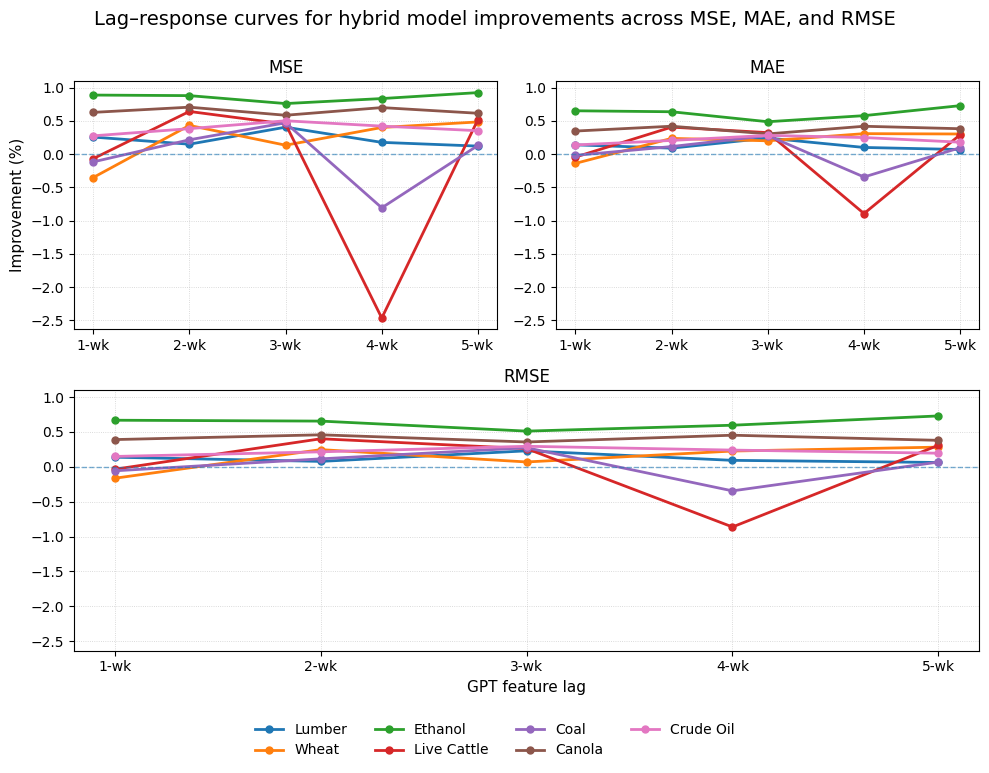

In [ ]:
# -----------------------------
# 1) User-configurable paths
# -----------------------------
RMSE_CSV = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/rmse_changes.csv"
MSE_CSV  = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/mse_changes.csv"
MAE_CSV  = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/mae_changes.csv"

lag_cols = ['1-week Lag', '2-week Lag', '3-week Lag', '4-week Lag', '5-week Lag']
wanted_commodities = ['Lumber', 'Ethanol', 'Canola', 'Crude Oil', 'Wheat', 'Live Cattle', 'Coal']

def load_and_prepare(csv_path, wanted):
    df = pd.read_csv(csv_path)
    df[lag_cols] = df[lag_cols].apply(pd.to_numeric, errors='coerce')

    # case-insensitive matching
    lower_map = {name.lower(): name for name in df['Commodity']}
    matched = [lower_map[w.lower()] for w in wanted if w.lower() in lower_map]

    df_sub = df[df['Commodity'].isin(matched)].copy()
    Y = -df_sub[lag_cols].to_numpy()  # flip sign so positive = improvement
    names = df_sub['Commodity'].tolist()
    return names, Y

# -----------------------------
# 2) Load all three metrics
# -----------------------------
names1, Y_rmse = load_and_prepare(RMSE_CSV, wanted_commodities)
names2, Y_mse  = load_and_prepare(MSE_CSV,  wanted_commodities)
names3, Y_mae  = load_and_prepare(MAE_CSV,  wanted_commodities)

assert names1 == names2 == names3, "Commodity ordering mismatch!"
commodities = names1

# -----------------------------
# 3) Global y-axis limits
# -----------------------------
all_vals = np.concatenate([Y_mse.flatten(), Y_mae.flatten(), Y_rmse.flatten()])
all_vals = all_vals[~np.isnan(all_vals)]
y_min, y_max = all_vals.min(), all_vals.max()
margin = 0.05 * (y_max - y_min)
y_lim = (y_min - margin, y_max + margin)

x = np.arange(1, 6)
x_labels = ['1-wk', '2-wk', '3-wk', '4-wk', '5-wk']

# consistent colors
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [color_cycle[i % len(color_cycle)] for i in range(len(commodities))]

# -----------------------------
# 4) Custom GridSpec layout
# -----------------------------
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 2, height_ratios=[1, 1.05])  # slightly more room for bottom centered plot

ax_mse = fig.add_subplot(gs[0, 0])
ax_mae  = fig.add_subplot(gs[0, 1])
ax_rmse  = fig.add_subplot(gs[1, :])  # spans entire bottom row

def plot_metric(ax, Y, title, ylabel=None):
    for i, comm in enumerate(commodities):
        ax.plot(
            x, Y[i, :],
            marker='o',
            linewidth=2,
            markersize=5,
            color=colors[i],
            label=comm
        )
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)
    ax.set_ylim(y_lim)
    ax.set_title(title, fontsize=12)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11)

# plot all metrics
plot_metric(ax_mse, Y_mse, "MSE", ylabel="Improvement (%)")
plot_metric(ax_mae,  Y_mae,  "MAE")
plot_metric(ax_rmse,  Y_rmse,  "RMSE")
ax_rmse.set_xlabel("GPT feature lag", fontsize=11)

# -----------------------------
# 5) Unified legend
# -----------------------------
handles, labels = ax_mse.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.0),
           ncol=4,
           frameon=False)

# -----------------------------
# 6) Overall figure title
# -----------------------------
fig.suptitle(
    "Lag–response curves for hybrid model improvements across MSE, MAE, and RMSE",
    fontsize=14, y=1
)

plt.tight_layout()
# fig.savefig("figure2_three_metric_lag_response.png", dpi=300, bbox_inches='tight')
plt.show()

## Figure 3: Network Schematic of Cascading Commodity Relationships

*   Demonstrates directed networks of weather event effect propagation paths (e.g. Drought --> Corn --> Feed --> Cattle --> Poultry
*   Intended to link statistical results to physical and market mechanisms (NCC expectation)

Description:

*Figure 3. Conceptual network of cascading commodity linkages inferred through GPT-derived features. Climate shocks propagate from directly affected commodities to downstream markets through supply and demand dependencies.*




In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

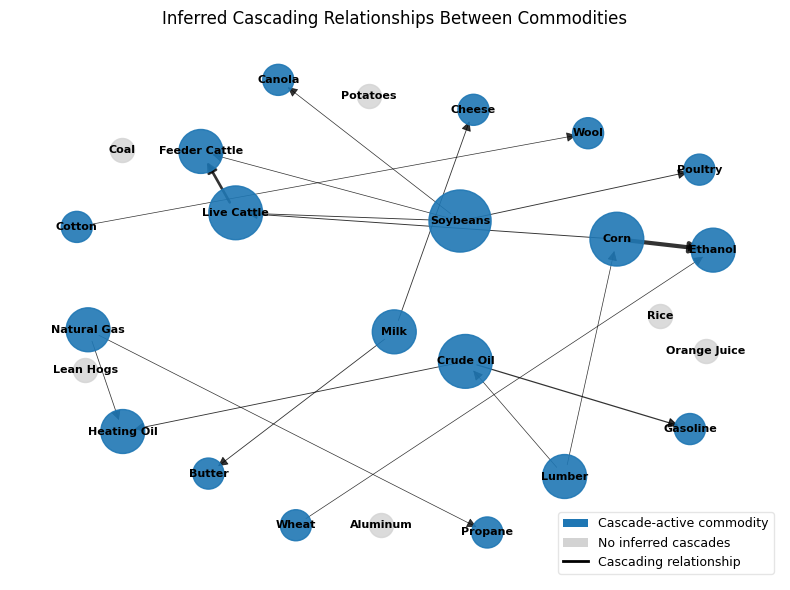

In [7]:
# ----------------------------------------------------
# 1. Load cascading edges and aggregate them
# ----------------------------------------------------
edges_path = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/features/cascading_edges.csv"
df_edges = pd.read_csv(edges_path)

all_commodities = [
    'cotton', 'orange_juice', 'lumber', 'corn', 'propane',
    'natural_gas', 'soybeans', 'wheat', 'ethanol', 'live_cattle',
    'feeder_cattle', 'lean_hogs', 'coal', 'heating_oil', 'potatoes',
    'wool', 'milk', 'canola', 'poultry', 'butter', 'cheese',
    'rice', 'crude_oil', 'gasoline', 'aluminum'
]

df_edges = df_edges[
    df_edges["source_commodity"].isin(all_commodities)
    & df_edges["target_commodity"].isin(all_commodities)
]

# Name convention helper function
def format_name(name):
    return name.replace("_", " ").title()

# Optional: restrict to test period only
# df_edges['start_week'] = pd.to_datetime(df_edges['start_week'])
# test_start = pd.to_datetime("2023-10-02")   # example, adjust to your split
# test_end   = pd.to_datetime("2024-12-30")
# df_edges = df_edges[(df_edges['start_week'] >= test_start) & (df_edges['start_week'] <= test_end)]

# Aggregate by (source, target) across all events and weeks
agg = (
    df_edges
    .groupby(['source_commodity', 'target_commodity'], as_index=False)
    .agg(total_weight=('impact_factor', 'sum'))
)

# If you want to ignore very tiny links:
weight_threshold = 0.0  # you can bump to e.g. 0.05 if it is too dense
agg = agg[agg['total_weight'] > weight_threshold]

# ----------------------------------------------------
# 2. Build the directed graph
# ----------------------------------------------------
G = nx.DiGraph()

# Add edges with weight attribute
for _, row in agg.iterrows():
    src = row['source_commodity']
    tgt = row['target_commodity']
    w   = row['total_weight']
    G.add_edge(src, tgt, weight=w)

# Add all 25 commodities as nodes (so isolates appear too)
G.add_nodes_from(all_commodities)

# ----------------------------------------------------
# 3. Compute layout and centrality
# ----------------------------------------------------
# Force-directed layout (spring)
pos = nx.spring_layout(G, seed=42, k=1.6)  # tweak k for more/less spread

# Degree centrality for active nodes (only nodes with edges will have degree > 0)
deg_centrality = nx.degree_centrality(G)

# Split nodes into active vs isolated
active_nodes   = [n for n in G.nodes if G.degree(n) > 0]
isolated_nodes = [n for n in G.nodes if G.degree(n) == 0]

# Node sizes: scale by degree centrality (for active nodes)
if active_nodes:
    active_vals = np.array([deg_centrality[n] for n in active_nodes])
    # Rescale to something visually reasonable
    min_size, max_size = 500, 2000
    if active_vals.max() > 0:
        scaled_sizes = min_size + (active_vals - active_vals.min()) / max(
            1e-8, (active_vals.max() - active_vals.min())
        ) * (max_size - min_size)
    else:
        scaled_sizes = np.full_like(active_vals, (min_size + max_size) / 2)
else:
    scaled_sizes = []

# ----------------------------------------------------
# 4. Draw the network (aesthetics tuned for a paper)
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Draw edges
edges = G.edges(data=True)
if edges:
    weights = np.array([d['weight'] for (_, _, d) in edges])
    # Normalize widths into a nice range
    min_w, max_w = 0.5, 3.0
    if weights.max() > 0:
        edge_widths = min_w + (weights - weights.min()) / max(
            1e-8, (weights.max() - weights.min())
        ) * (max_w - min_w)
    else:
        edge_widths = np.full_like(weights, (min_w + max_w) / 2)

    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v) for (u, v, _) in edges],
        width=edge_widths,
        alpha=0.8,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=15
    )

# Draw active nodes
if active_nodes:
    nodes_active = nx.draw_networkx_nodes(
        G, pos,
        nodelist=active_nodes,
        node_size=scaled_sizes,
        node_color='tab:blue',  # choose a clean color
        alpha=0.9
    )

# Draw isolated nodes (smaller, grey)
if isolated_nodes:
    nodes_iso = nx.draw_networkx_nodes(
        G, pos,
        nodelist=isolated_nodes,
        node_size=300,
        node_color='lightgray',
        alpha=0.8
    )

# Labels
labels = {node: format_name(node) for node in G.nodes()}
nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=8,
    font_family='sans-serif',
    font_weight='bold',
    )

# ----------------------------------------------------
# 5. Legend and layout tweaks
# ----------------------------------------------------
# Create proxy handles for legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = []

if active_nodes:
    legend_elements.append(
        Patch(facecolor='tab:blue', edgecolor='none', label='Cascade-active commodity')
    )
if isolated_nodes:
    legend_elements.append(
        Patch(facecolor='lightgray', edgecolor='none', label='No inferred cascades')
    )

if edges:
    legend_elements.append(
        Line2D([0], [0], color='black', lw=2, label='Cascading relationship')
    )

if legend_elements:
    ax.legend(
        handles=legend_elements,
        loc='lower right',
        frameon=True,
        framealpha=0.5,
        fontsize=9
    )

ax.set_axis_off()
ax.set_title("Inferred Cascading Relationships Between Commodities")

plt.tight_layout()
plt.savefig("figure_cascade_network.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import io

# Assume the previous steps in the schematic have been executed,
# meaning G (the graph), active_nodes, scaled_sizes, and edges are defined.

# --- Replicating Necessary Setup for Standalone Printing ---
# The code below relies on G, active_nodes, scaled_sizes, and edges
# being defined from the execution of steps 1, 2, 3, and 4 of your schematic.

# For this code to run successfully, you would need to execute all steps
# of the original schematic up to the point where 'G' and 'edges' are defined,
# but since you only provided the schematic text, the actual data loading
# and graph building are omitted here. We proceed assuming those objects exist.

# ----------------------------------------------------
# 1. Edge Weight Data (Top Edges)
# ----------------------------------------------------

# Retrieve all edges with their original 'weight'
all_edge_data = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]

# Create a DataFrame for easy sorting
if all_edge_data:
    df_edge_weights = pd.DataFrame(
        all_edge_data,
        columns=['Source', 'Target', 'Total_Weight']
    )

    # Sort by 'Total_Weight' descending
    df_edge_weights = df_edge_weights.sort_values(
        'Total_Weight',
        ascending=False
    ).reset_index(drop=True)

    print("## 🔝 Top 10 Edges (Commodity Cascades) by Total Weight")
    # Print the top 10 edges or all if less than 10
    print(df_edge_weights.head(10).to_string(index=False, float_format="%.4f"))
else:
    print("## 🔝 Top 10 Edges (Commodity Cascades) by Total Weight")
    print("No edges were found based on the provided data and weight_threshold.")


# ----------------------------------------------------
# 2. Node Size Data (Top Nodes by Degree Centrality/Size)
# ----------------------------------------------------

# Active nodes correspond to scaled_sizes
if active_nodes:
    # Create a DataFrame mapping active nodes to their scaled size
    df_node_sizes = pd.DataFrame({
        'Commodity': active_nodes,
        'Scaled_Node_Size': scaled_sizes
    })

    # Sort by 'Scaled_Node_Size' descending
    df_node_sizes = df_node_sizes.sort_values(
        'Scaled_Node_Size',
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "="*50 + "\n")
    print("## 📏 Top 10 Nodes by Size (Degree Centrality)")
    # Print the top 10 nodes or all if less than 10
    print(df_node_sizes.head(10).to_string(index=False, float_format="%.2f"))
else:
    print("\n" + "="*50 + "\n")
    print("## 📏 Top 10 Nodes by Size (Degree Centrality)")
    print("No active nodes were found (all commodities are isolated).")

# Note: Isolated nodes (those not in 'active_nodes') have a fixed size of 300
# and are not included in this "top size" list.

## 🔝 Top 10 Edges (Commodity Cascades) by Total Weight
     Source        Target  Total_Weight
       corn       ethanol      139.8000
live_cattle feeder_cattle       79.6000
  crude_oil      gasoline       22.0000
       corn   live_cattle        9.7000
   soybeans       poultry        8.5500
   soybeans   live_cattle        7.4000
  crude_oil   heating_oil        7.3000
       milk        butter        6.3000
       milk        cheese        6.3000
natural_gas   heating_oil        2.5000


## 📏 Top 10 Nodes by Size (Degree Centrality)
    Commodity  Scaled_Node_Size
     soybeans           2000.00
  live_cattle           1500.00
         corn           1500.00
    crude_oil           1500.00
      ethanol           1000.00
feeder_cattle           1000.00
       lumber           1000.00
         milk           1000.00
  heating_oil           1000.00
  natural_gas           1000.00


#### Interpretation of the Network graph

*   Node size
    * Bigger: More edges going in and out of that commodity, i.e. this commodity is invovled in many cascading relationships
    * Smaller: Fewer edges going in and out of that commodity, i.e. minimally involved in cascades
*   Edge thickness
    * Thicker: Indicates repeated or consistent high-impact cascades in a given direction between two commodities
    * Thinner: Infrequent or weaker cascades between the two commodities
* Edge Arrows:
    * An arrow A --> B indicates that disruptions in commodity A propagates to commodity B
* Node Position (Spacing)
    * Nodes closer together suggest tightly linked system
    * Nodes further apart suggest fewer or weaker connections
    * Clusters naturally form where many commodities share cascades
* Node Color
    * Blue: Indicates active nodes that have at least 1 cascading relationship
    * Grey: Does not appear in any cascade across the dataset







## Figure 4: Summary Bar Chart: Fraction of Commodities with Significant Hybrid Outperformance

Demonstrates a summary of Diebold-Mariano tests with commodities showing statistically significant hybrid improvements (i.e. p-value < 0.05)

What it shows:

*  X-axis: GPT lag (1 to 5 weeks)
*  Y-axis: Fraction (or percentage) of commodities with significant hybrid improvement (DM p < 0.05).
Optionally color bars by commodity class (e.g., Energy, Agriculture, Livestock).

Description:

*Figure 4. Share of commodities exhibiting statistically significant hybrid model outperformance across GPT-feature lags. The consistency across lags indicates that GPT-derived features capture persistent, interpretable weather-linked volatility signals.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

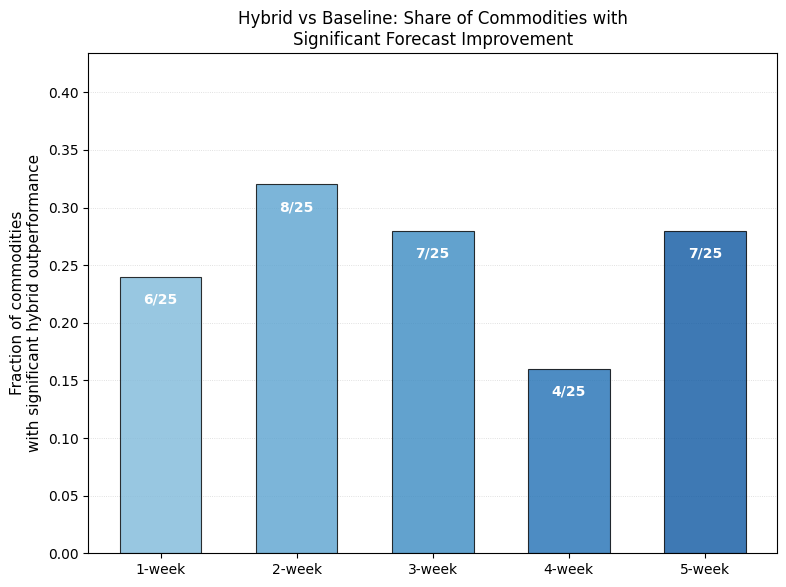

In [ ]:
# ---------- 1. Load data ----------
DM_CSV_PATH = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/dm_test_results.csv"
df_dm = pd.read_csv(DM_CSV_PATH)

# Make sure numeric
for lag in ["1w", "2w", "3w", "4w", "5w"]:
    df_dm[f"dm_{lag}"] = pd.to_numeric(df_dm[f"dm_{lag}"], errors="coerce")
    df_dm[f"pval_{lag}"] = pd.to_numeric(df_dm[f"pval_{lag}"], errors="coerce")

# ---------- 2. Compute counts, fractions, standard errors ----------
n_total = len(df_dm)  # should be 25

lag_codes   = ["1w", "2w", "3w", "4w", "5w"]
lag_labels  = ["1-week", "2-week", "3-week", "4-week", "5-week"]

counts = []
fractions = []
ses = []

for lag in lag_codes:
    mask_sig_hybrid = (df_dm[f"dm_{lag}"] > 0) & (df_dm[f"pval_{lag}"] < 0.05)
    count = mask_sig_hybrid.sum()
    frac = count / n_total
    se = np.sqrt(frac * (1 - frac) / n_total)  # binomial standard error

    counts.append(count)
    fractions.append(frac)
    ses.append(se)

counts = np.array(counts)
fractions = np.array(fractions)
ses = np.array(ses)

# ---------- 3. Set up aesthetics ----------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

x = np.arange(len(lag_labels))

# Use a nice gradient of blues
cmap = plt.cm.Blues
bar_colors = cmap(np.linspace(0.45, 0.85, len(lag_labels)))

fig, ax = plt.subplots(figsize=(8, 6))

# ---------- 4. Plot bars with error bars ----------
bar_width = 0.6

bars = ax.bar(
    x,
    fractions,
    #yerr=ses,
    width=bar_width,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    #capsize=4,
    #error_kw=dict(elinewidth=1.0, alpha=0.8)
)

# ---------- 5. Axes, grid, limits ----------
ax.set_xticks(x)
ax.set_xticklabels(lag_labels)
ax.set_ylabel("Fraction of commodities\nwith significant hybrid outperformance")
ax.set_ylim(0, 1.05 * max(1.0 / n_total, fractions.max() + ses.max()))  # small headroom

# Light horizontal gridlines
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)
ax.set_axisbelow(True)  # grid behind bars

# Optional title (can remove if you will add a LaTeX caption instead)
ax.set_title("Hybrid vs Baseline: Share of Commodities with\nSignificant Forecast Improvement")

# ---------- 6. Annotate bars with counts (and optional %s) ----------
for bar, count, frac in zip(bars, counts, fractions):
    x_center = bar.get_x() + bar.get_width() / 2
    # Place the "x/25" count inside the bar, near the top
    y_text = frac - 0.02  # slightly below the top of the bar
    if y_text < 0.03:     # if the bar is tiny, place the text above instead
        y_text = frac + 0.02

    ax.text(
        x_center,
        y_text,
        f"{count}/{n_total}",
        ha="center",
        va="center",
        color="white" if y_text < frac else "black",
        fontsize=10,
        fontweight="bold"
    )

    # Optional: uncomment to also show percentage above the bar
    # ax.text(
    #     x_center,
    #     frac + 0.04,
    #     f"{frac*100:.0f}%",
    #     ha="center",
    #     va="bottom",
    #     color="black",
    #     fontsize=9
    # )

plt.tight_layout()
plt.savefig("figure_fraction_significant_hybrid.png", dpi=600, bbox_inches="tight")
plt.show()


## Table 1: Key Statistical Summary

Data Source:

Condensed from Tables 11 and 16 (5-week GPT lag results).

What it shows:

Only top-performing and representative commodities (e.g., Lumber, Ethanol, Canola, Crude Oil, Wheat, Live Cattle).

Columns:
* Commodity
* % RMSE Improvement
* DM Statistic
* p-value
* Significance (✓/×)

Description:

*Table 1. Representative hybrid model improvements and Diebold–Mariano test results for key commodities under the 5-week GPT-lag configuration.*

## Figure 5: Sector-Level Box Plot

Plot:

* x-axis = sector (e.g., Energy, Field Crops, Livestock, Softs, Industrials)
* y-axis = % RMSE improvement
* Each point = a commodity
* DM-significant commodities marked with a special symbol
* Optional: one figure per lag (5 panels) OR a single panel combining all lags with jitter.

Why this is excellent:

* Shows sector-level climate sensitivity revealed through forecasting gains
* Makes clear which sectors the NOAA test-period weather events hit hardest
* Helps justify why lumber, ethanol, canola, crude oil show consistent improvements
* Visually very clean and NCC-friendly

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

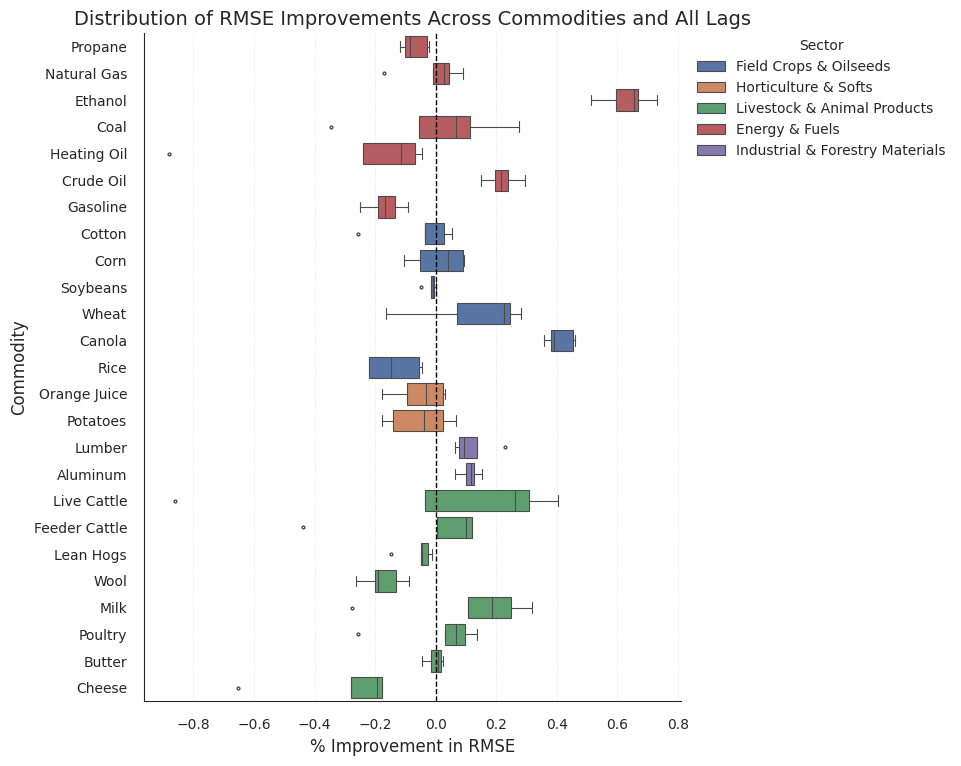

In [ ]:
# ============================================================
# 1. Load data
# ============================================================

# Edit this path as needed
csv_path = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/rmse_changes.csv"

df = pd.read_csv(csv_path)

# Assume:
# - First column = commodity name
# - Remaining columns = RMSE changes for different lags
commodity_col = df.columns[0]
lag_cols = df.columns[1:]

# ============================================================
# 2. Wide → long + flip sign so positive = improvement
# ============================================================

df_long = df.melt(
    id_vars=commodity_col,
    value_vars=lag_cols,
    var_name="Lag",
    value_name="rmse_change"
)

# Flip sign: positive = improvement
df_long["rmse_improvement"] = -df_long["rmse_change"]

# Drop rows with missing values (if any)
df_long = df_long.dropna(subset=["rmse_improvement"])

# ============================================================
# 3. Map commodities to sectors
# ============================================================

sector_map = {
    # Field Crops & Oilseeds
    "Corn": "Field Crops & Oilseeds",
    "Soybeans": "Field Crops & Oilseeds",
    "Wheat": "Field Crops & Oilseeds",
    "Canola": "Field Crops & Oilseeds",
    "Rice": "Field Crops & Oilseeds",
    "Cotton": "Field Crops & Oilseeds",

    # Horticulture & Softs
    "Potatoes": "Horticulture & Softs",
    "Orange Juice": "Horticulture & Softs",

    # Livestock & Animal Products
    "Live Cattle": "Livestock & Animal Products",
    "Feeder Cattle": "Livestock & Animal Products",
    "Lean Hogs": "Livestock & Animal Products",
    "Poultry": "Livestock & Animal Products",
    "Milk": "Livestock & Animal Products",
    "Butter": "Livestock & Animal Products",
    "Cheese": "Livestock & Animal Products",
    "Wool": "Livestock & Animal Products",

    # Energy & Fuels
    "Crude Oil": "Energy & Fuels",
    "Gasoline": "Energy & Fuels",
    "Natural Gas": "Energy & Fuels",
    "Propane": "Energy & Fuels",
    "Heating Oil": "Energy & Fuels",
    "Coal": "Energy & Fuels",
    "Ethanol": "Energy & Fuels",

    # Industrial & Forestry Materials
    "Lumber": "Industrial & Forestry Materials",
    "Aluminum": "Industrial & Forestry Materials",
}

df_long["Sector"] = df_long[commodity_col].map(sector_map)

# If any commodities are missing from sector_map, they’ll show up as NaN
if df_long["Sector"].isna().any():
    missing = df_long.loc[df_long["Sector"].isna(), commodity_col].unique()
    print("WARNING: Missing sector mapping for:", missing)

# ============================================================
# 4. Order commodities grouped by sector for clean structure
# ============================================================

# Get one sector per commodity
commodity_sector = (
    df_long[[commodity_col, "Sector"]]
    .drop_duplicates()
    .set_index(commodity_col)["Sector"]
)

# Order commodities by sector, then alphabetically within sector
commodity_order = (
    commodity_sector
    .sort_values(kind="mergesort")  # stable sort
    .index
    .tolist()
)

# Also define a consistent sector order
sector_order = [
    "Field Crops & Oilseeds",
    "Horticulture & Softs",
    "Livestock & Animal Products",
    "Energy & Fuels",
    "Industrial & Forestry Materials",
]

# ============================================================
# 5. NCC-style aesthetics and boxplot
# ============================================================

sns.set_theme(style="white", context="talk")

fig, ax = plt.subplots(figsize=(10, 8))

# Horizontal boxplot, commodities on y-axis, colored by sector
sns.boxplot(
    data=df_long,
    x="rmse_improvement",
    y=commodity_col,
    hue="Sector",
    order=commodity_order,
    hue_order=[s for s in sector_order if s in df_long["Sector"].unique()],
    orient="h",
    fliersize=2,
    linewidth=0.8,
    ax=ax
)

# Vertical line at 0 (no change)
ax.axvline(0, color="black", linewidth=1, linestyle="--")

# Labels and title (adjust text as needed for the paper)
ax.set_xlabel("% Improvement in RMSE", fontsize=12)
ax.set_ylabel("Commodity", fontsize=12)
ax.set_title("Distribution of RMSE Improvements Across Commodities and All Lags", fontsize=14)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

# Clean NCC-style look: minimal spines, light grid on x-axis only
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.grid(True, axis="x", linestyle=":", linewidth=0.6, alpha=0.6)
ax.grid(False, axis="y")

# Move legend outside
ax.legend(
    title="Sector",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
    prop={"size": 10},
    title_fontsize=10
)

plt.tight_layout()
plt.show()

# Optionally save to file (for the paper)
fig.savefig("rmse_improvement_boxplot_by_commodity.png", dpi=600, bbox_inches="tight")

Sector order by median improvement:
 Sector
Industrial & Forestry Materials    10.9090
Field Crops & Oilseeds             -0.1825
Livestock & Animal Products        -1.9980
Energy & Fuels                     -2.3190
Horticulture & Softs               -3.4905
Name: rmse_improvement, dtype: float64


/tmp/ipykernel_8534/2562767442.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


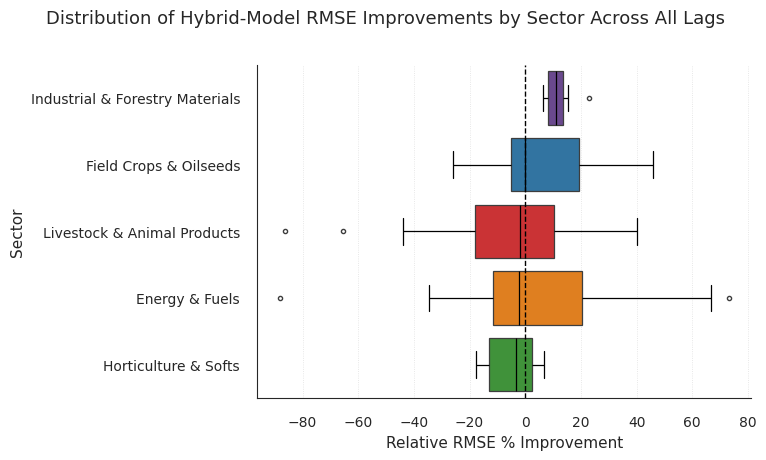

In [7]:
# ============================================================
# 1. Load data
# ============================================================

# Edit this path as needed
csv_path = "/content/drive/MyDrive/Research/Julia_Thesis_Contd/results - shyam/rmse_changes.csv"

df = pd.read_csv(csv_path)

# Assume:
# - First column = commodity name
# - Remaining columns = percentage changes in RMSE for different lags:
#   (rmse_hybrid - rmse_baseline) / rmse_baseline
commodity_col = df.columns[0]
lag_cols = df.columns[1:]

# ============================================================
# 2. Wide → long and convert to "improvement"
# ============================================================

df_long = df.melt(
    id_vars=commodity_col,
    value_vars=lag_cols,
    var_name="Lag",
    value_name="rmse_pct_change"   # relative change: (hybrid - baseline)/baseline
)

# Flip sign so positive = improvement (lower RMSE than baseline)
df_long["rmse_improvement"] = -df_long["rmse_pct_change"]*100

# Drop rows with missing values (if any)
df_long = df_long.dropna(subset=["rmse_improvement"])

# ============================================================
# 3. Map commodities → sectors
# ============================================================

sector_map = {
    # Field Crops & Oilseeds
    "Corn": "Field Crops & Oilseeds",
    "Soybeans": "Field Crops & Oilseeds",
    "Wheat": "Field Crops & Oilseeds",
    "Canola": "Field Crops & Oilseeds",
    "Rice": "Field Crops & Oilseeds",
    "Cotton": "Field Crops & Oilseeds",

    # Horticulture & Softs
    "Potatoes": "Horticulture & Softs",
    "Orange Juice": "Horticulture & Softs",

    # Livestock & Animal Products
    "Live Cattle": "Livestock & Animal Products",
    "Feeder Cattle": "Livestock & Animal Products",
    "Lean Hogs": "Livestock & Animal Products",
    "Poultry": "Livestock & Animal Products",
    "Milk": "Livestock & Animal Products",
    "Butter": "Livestock & Animal Products",
    "Cheese": "Livestock & Animal Products",
    "Wool": "Livestock & Animal Products",

    # Energy & Fuels
    "Crude Oil": "Energy & Fuels",
    "Gasoline": "Energy & Fuels",
    "Natural Gas": "Energy & Fuels",
    "Propane": "Energy & Fuels",
    "Heating Oil": "Energy & Fuels",
    "Coal": "Energy & Fuels",
    "Ethanol": "Energy & Fuels",

    # Industrial & Forestry Materials
    "Lumber": "Industrial & Forestry Materials",
    "Aluminum": "Industrial & Forestry Materials",
}

df_long["Sector"] = df_long[commodity_col].map(sector_map)

# Keep only rows with a valid sector
df_sector = df_long.dropna(subset=["Sector"]).copy()

# Warn if something didn't get mapped
if df_sector.shape[0] != df_long.shape[0]:
    missing = df_long.loc[df_long["Sector"].isna(), commodity_col].unique()
    if len(missing) > 0:
        print("WARNING: Missing sector mapping for:", missing)

# ============================================================
# 4. Define sector order (by median improvement, descending)
# ============================================================

sector_medians = (
    df_sector
    .groupby("Sector")["rmse_improvement"]
    .median()
    .sort_values(ascending=False)
)

sector_order = sector_medians.index.tolist()
print("Sector order by median improvement:\n", sector_medians)

# ============================================================
# 5. NCC-style sector-level boxplot
# ============================================================

sns.set_theme(style="white", context="talk")

# Define a clean NCC-style sector palette (adjust if you prefer)
sector_palette = {
    "Field Crops & Oilseeds": "#1f78b4",        # muted blue
    "Horticulture & Softs": "#33a02c",          # muted green
    "Livestock & Animal Products": "#e31a1c",   # muted red
    "Energy & Fuels": "#ff7f00",                # muted orange
    "Industrial & Forestry Materials": "#6a3d9a" # muted purple
}

fig, ax = plt.subplots(figsize=(8, 5))

# One box per sector: aggregate all commodities and lags within each sector
sns.boxplot(
    data=df_sector,
    x="rmse_improvement",
    y="Sector",
    order=sector_order,
    orient="h",
    color="white",      # single neutral fill; NCC-style minimalism
    fliersize=3,
    linewidth=0.9,
    ax=ax,
    palette=sector_palette
)

# Draw median lines in a subtle way (already handled by seaborn,
# but this keeps edges visible against white fill)
for patch in ax.artists:
    patch.set_edgecolor("black")
    patch.set_facecolor("white")

for line in ax.lines:
    line.set_color("black")
    line.set_linewidth(0.9)

# Vertical line at 0 = no change
ax.axvline(0, color="black", linewidth=1, linestyle="--")

# Axis labels and title
ax.set_xlabel("Relative RMSE % Improvement", fontsize=11)
ax.set_ylabel("Sector", fontsize=11)
ax.set_title("Distribution of Hybrid-Model RMSE Improvements by Sector Across All Lags", fontsize=13, y=1.1, x=0.26)

# Tick label sizes (NCC style: clean and slightly smaller)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# Clean NCC-style spines and grid
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# Light grid only on x-axis
ax.grid(True, axis="x", linestyle=":", linewidth=0.6, alpha=0.6)
ax.grid(False, axis="y")

# Optional: automatically set x-limits so all values (including extreme outliers) are visible
min_val = df_sector["rmse_improvement"].min()
max_val = df_sector["rmse_improvement"].max()
margin = 0.05 * (max_val - min_val) if max_val > min_val else 0.1
ax.set_xlim(min_val - margin, max_val + margin)

plt.tight_layout()
plt.show()

# Optional: save for the paper
fig.savefig("boxplot_sector.png", dpi=600, bbox_inches="tight")